In [1]:
import pandas as pd
import numpy as np
import hist
import matplotlib as mpl
import mplhep
#import mplhep.error_estimation will come back to this later
mpl.style.use(mplhep.style.ROOT)
import matplotlib.pyplot as plt
import scipy
from scipy import optimize
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import yaml
from statistics import mean 

In [9]:

# {"parameter_points_file":"link_0_inv_vref_scan_settings.csv","channel":0,"nevents_per_point":1,"trigger":"PEDESTAL","scan_wide_params":{}}

inv_vref_test = pd.read_csv('link_0_inv_vref_scan_settings_20250725_181043.csv')

In [10]:
plt.scatter(inv_vref_test.INV_VREF, inv_vref_test.adc)
#plt.axhline(y=50, color='g')
plt.axvline(x=530, color='g')
#plt.ylim(top = 100)
#plt.xlim(left = 400, right = 540)
plt.xlabel("INV_VREF")
plt.ylabel("ADC")
plt.title("Link 0 - channel 0")

AttributeError: 'DataFrame' object has no attribute 'INV_VREF'

In [8]:
inv_vref_test[(inv_vref_test.INV_VREF>=530)]

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
1420,530,False,False,35,33,-1,0
1421,530,False,False,36,35,-1,0
1422,530,False,False,35,35,-1,0
1423,530,False,False,37,35,-1,0
1424,530,False,False,35,35,-1,0
...,...,...,...,...,...,...,...
2725,600,False,False,11,11,-1,0
2726,600,False,False,10,10,-1,0
2727,600,False,False,12,11,-1,0
2728,600,False,False,11,11,-1,0


In [44]:
inv_vref_test.describe()

,INV_VREF,adc_tm1,adc,tot,toa
count,2730.000000,2730.000000,2730.000000,2730.0,2730.0
mean,492.934066,91.298901,91.283150,-1.0,0.0
std,104.165370,108.659193,108.682624,0.0,0.0
min,0.000000,9.000000,9.000000,-1.0,0.0
25%,456.000000,11.000000,11.000000,-1.0,0.0
50%,521.000000,47.000000,47.000000,-1.0,0.0
75%,555.000000,141.000000,141.000000,-1.0,0.0
max,600.000000,528.000000,528.000000,-1.0,0.0


In [6]:
np.round(mean(list(inv_vref_test.INV_VREF[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]))) #LINK 0 mean inv_vref that'll give us 50 +/- 1 for adc

520.0

In [15]:
# {"parameter_points_file":"link_1_inv_vref_scan_setting.csv","channel":71,"nevents_per_point":1,"trigger":"PEDESTAL","scan_wide_params":{}}


inv_vref_test = pd.read_csv('link_1_inv_vref_scan_setting_20250725_182348.csv')

Text(0.5, 1.0, 'Link 1 - channel 71')

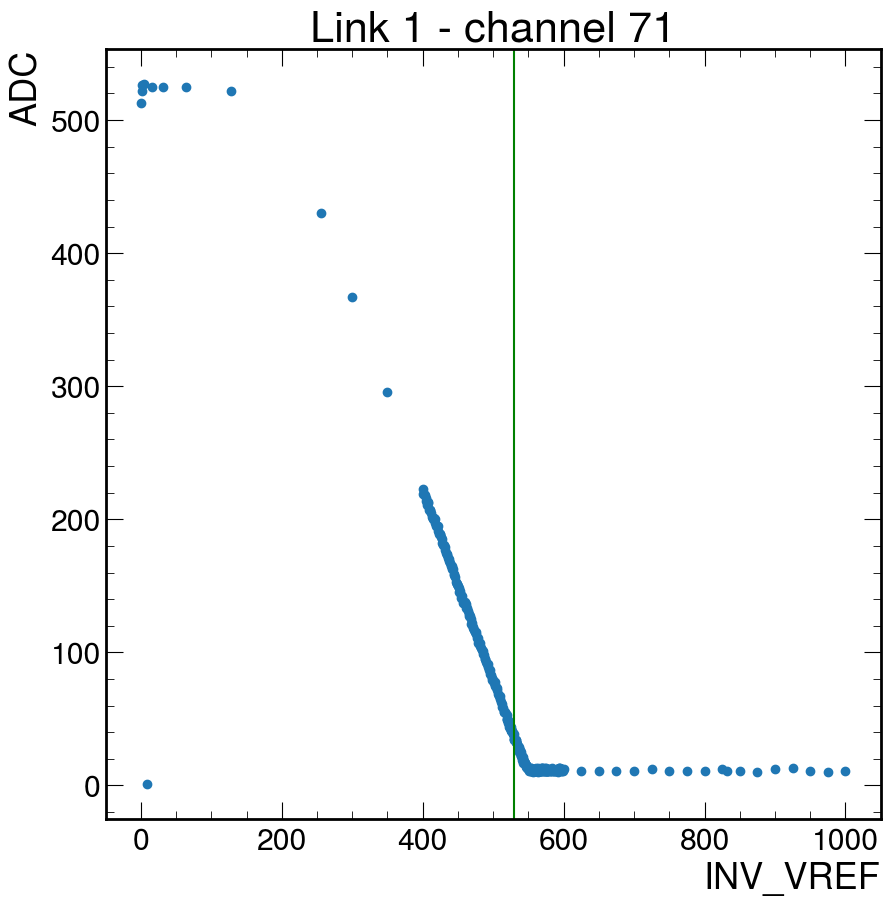

In [5]:
plt.scatter(inv_vref_test.INV_VREF, inv_vref_test.adc)
#plt.axhline(y=50, color='g')
plt.axvline(x=530, color='g')
#plt.ylim(top = 100)
#plt.xlim(left = 500)
plt.xlabel("INV_VREF")
plt.ylabel("ADC")
plt.title("Link 1 - channel 71")

In [10]:
np.round(mean(list(inv_vref_test.INV_VREF[(inv_vref_test.adc>=49) & (inv_vref_test.adc <=51)]))) #LINK 1 mean inv_vref that'll give us 50 +/- 1 for adc

512.0

In [31]:
inv_vref_test.tail()

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
2855,2048,False,False,512,512,-1,0
2856,2048,False,False,512,512,-1,0
2857,2048,False,False,512,512,-1,0
2858,2048,False,False,512,512,-1,0
2859,2048,False,False,512,512,-1,0


In [19]:
### minimum adc value is 18, seen lastly at 592
inv_vref_test[inv_vref_test.adc <= 18]

,INV_VREF,Tp,Tc,adc_tm1,adc,tot,toa
1733,561,False,False,21,18,-1,0
1766,564,False,False,19,18,-1,0
1886,576,False,False,21,18,-1,0
1890,577,False,False,19,18,-1,0
2326,560,False,False,19,18,-1,0
2473,575,False,False,19,18,-1,0
2582,586,False,False,20,18,-1,0
2647,592,False,False,19,18,-1,0


Text(0.5, 1.0, 'Link 1 - channel 71')

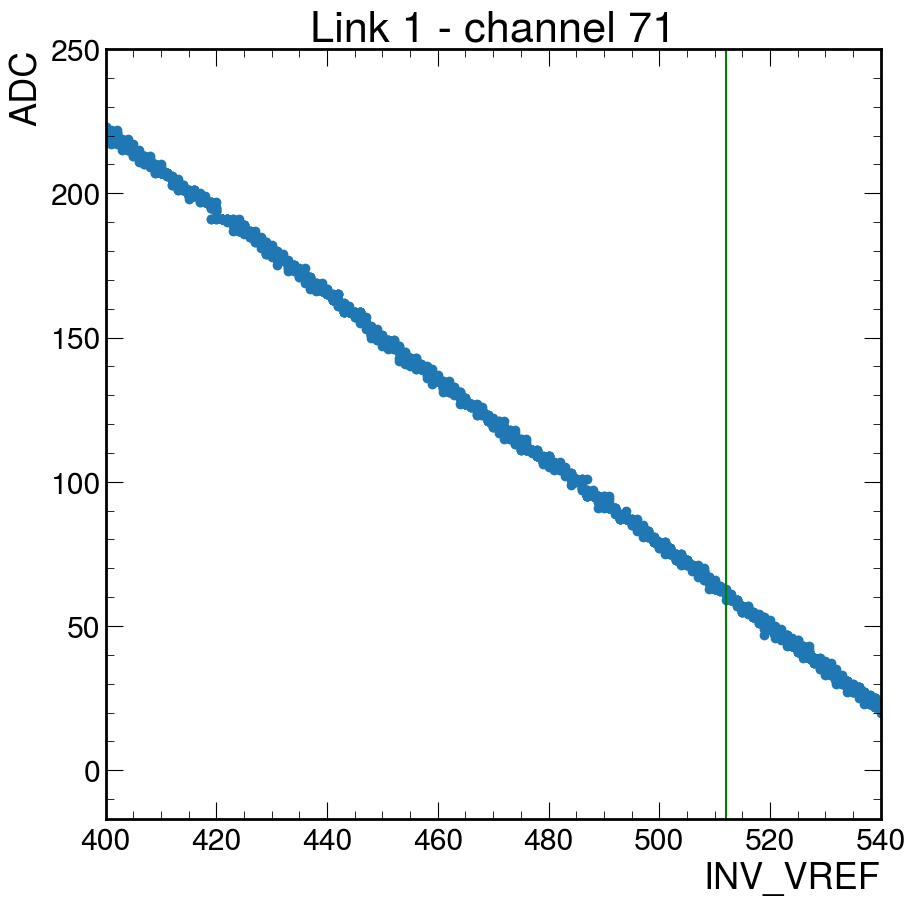

In [52]:
##what's happening above 592?
plt.scatter(inv_vref_test.INV_VREF, inv_vref_test.adc)
#plt.axhline(y=50, color='g')
plt.axvline(x=512, color='g')
plt.ylim(top = 250)
plt.xlim(left = 400 ,right = 540)
plt.xlabel("INV_VREF")
plt.ylabel("ADC")
plt.title("Link 1 - channel 71")
### looks like maybe the median lowest is 20, after 692 we se it between 19 and 21

In [ ]:
can i use their default setting of 416 as the low and have the high be 540? to avoid the plataeu?

In [ ]:
channels_settings = {}
#default_triminv= 0
#default_dacb = 0
#default_sign_dac = 0
neg_sign_dac = 1
trim_inv = [0,63]
dacb = [31,0]
#dacb_channels = []
for a in range(36):
    name = "CH_" + str(a)
    if l0_ch_med[a] < link_0_median :
        adc_values = [l0_ch_med[a],highlink_0_med[a]]
        new_triminv = round(np.interp(link_0_median, adc_values, trim_inv))
        channels_settings[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_0_med[a], l0_ch_med[a]]
        new_dacb = round(np.interp(link_0_median, adc_values, dacb))
        channels_settings[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
for b in range(36):
    name = "CH_" + str(b+36)
    if l1_ch_med[b] < link_1_median :
        adc_values = [l1_ch_med[b],highlink_1_med[b]]
        new_triminv = round(np.interp(link_1_median, adc_values, trim_inv))
        channels_settings[name] ={"TRIM_INV" : new_triminv}
    else:
        adc_values = [dacb_link_1_med[b],l1_ch_med[b]]
        new_dacb = round(np.interp(link_1_median, adc_values, dacb))
        channels_settings[name] ={"DACB" : new_dacb, "SIGN_DAC": neg_sign_dac}
            